In [1]:
import illustris_python as il
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

In [2]:
# CONFIGURAÇÕES

basePath       = '../sims.TNG/TNG50-3/output/'
snapshot_num   = 59          # alterar para z = 0, z = 0.5 ou z = 0.7
zred           = 0.7
afactor        = 1.0 / (1 + zred)

radius_cut     = 300.0       # raio máximo de análise (kpc/h)
icl_limit      = 5           # múltiplo do R_half para definir ICL                  

radii_bins     = np.arange(0, radius_cut + 10, 10)  # bins de 10 kpc/h
radius_centers = (radii_bins[1:] + radii_bins[:-1]) / 2.0

# Idade do universo
from astropy.cosmology import Planck15
import astropy.units as u
age_universe_gyr = Planck15.age(zred).to(u.Gyr).value
age_universe_gyr

7.310025232604206

In [3]:
halos = il.groupcat.loadHalos(basePath, snapshot_num,
    fields=['GroupFirstSub', 'Group_M_Mean200', 'GroupPos', 'Group_R_Mean200'])

subhalos = il.groupcat.loadSubhalos(basePath, snapshot_num,
    fields=['SubhaloFlag', 'SubhaloPos', 'SubhaloHalfmassRad',
            'SubhaloMass', 'SubhaloStellarPhotometrics'])

stars = il.snapshot.loadSubset(basePath, snapshot_num, 'stars',
    fields=['Coordinates', 'Velocities', 'Masses',
            'GFM_Metallicity', 'GFM_StellarFormationTime'])

In [4]:
# SELECIONAR HALOS MASSIVOS
# Group_M_Mean200 > 5e3 

ind, = np.where(halos['Group_M_Mean200'] > 5.0e3)
print(f"Halos selecionados: {len(ind)}")
print(f"log10(M200) = {np.log10(halos['Group_M_Mean200'][ind]) + 10.0}")

Halos selecionados: 1
log10(M200) = [13.8532295]


In [5]:
# FUNÇÃO: ESTIMAR COR g-r POR PARTÍCULA ESTELAR

def estimate_gr_color(metallicity, formation_time_scalefactor):
    """
    Estima a cor g-r de cada partícula estelar a partir de
    metalicidade e idade estelar.

    No IllustrisTNG:
      - GFM_Metallicity: fração de massa em metais (Z), adimensional
      - GFM_StellarFormationTime: fator de escala 'a' no momento de
        formação da estrela. Estrelas com valor negativo são partículas
        de vento e devem ser excluídas.

    Relação empírica aproximada (Bell et al. 2003 / Into & Portinari 2013):
      g-r ≈ 0.565 * log10(M/L_r) + constante
    Aqui usamos uma relação simplificada baseada em Z e idade:
      g-r ≈ a * log10(Z/Z_sun) + b * log10(age_Gyr) + c
    """
    
    Z_sun = 0.0127  # metalicidade solar

    # Filtrar partículas de vento (formation_time < 0)
    valid = formation_time_scalefactor > 0

    # Idade estelar em Gyr (aproximação simples para z=0)
    # age = (1 - a_form) * age_universe  [aproximação linear]
    age_gyr = np.where(valid, (1.0 - formation_time_scalefactor) * age_universe_gyr, np.nan)
    age_gyr = np.clip(age_gyr, 0.01, age_universe_gyr)  # evitar log(0)

    Z = np.clip(metallicity, 1e-6, None)  # evitar log(0)
    log_Z_Zsun = np.log10(Z / Z_sun)
    log_age    = np.log10(age_gyr)

    # Coeficientes empíricos (calibrados aproximadamente no TNG/BC03)
    # Populações mais velhas e mais metálicas → mais vermelhas
    a = 0.10   # contribuição da metalicidade
    b = 0.20   # contribuição da idade
    c = 0.45   # offset (cor típica de uma galáxia elíptica ~ 0.7)

    gr_color = a * log_Z_Zsun + b * log_age + c

    # Marcar partículas de vento como NaN
    gr_color[~valid] = np.nan

    return gr_color, valid

In [6]:
# LOOP PRINCIPAL: POR HALO

# Acumuladores para empilhar vários halos

all_gr_icl     = []
all_dist_icl   = []
all_mass_icl   = []
all_gr_noicl   = []
all_dist_noicl = []
all_mass_noicl = []

for i in ind[:1]:  # mudar para ind[:N] se for usar N halos

    print(f"\n--- Processando halo {i} ---")
    halo_cent = halos['GroupPos'][i, :]


    # Distância dos subhalos ao centro do halo

    subhalo_dist = np.sqrt(
        (subhalos['SubhaloPos'][:, 0] - halo_cent[0])**2 +
        (subhalos['SubhaloPos'][:, 1] - halo_cent[1])**2 +
        (subhalos['SubhaloPos'][:, 2] - halo_cent[2])**2)
    subhalo_dist_ind, = np.where(subhalo_dist < radius_cut + 100)


    # Distância das estrelas ao centro do halo

    dist_stars = np.sqrt(
        (stars['Coordinates'][:, 0] - halo_cent[0])**2 +
        (stars['Coordinates'][:, 1] - halo_cent[1])**2 +
        (stars['Coordinates'][:, 2] - halo_cent[2])**2)
    
    # Selecionar estrelas dentro do raio de análise
    dist_ind, = np.where((dist_stars < radius_cut) & (dist_stars > 5))
    print(f"  Estrelas no raio de análise: {len(dist_ind)}")

    # Calcular cor g-r para cada partícula estelar
    
    gr_all, valid_mask = estimate_gr_color(
        stars['GFM_Metallicity'][dist_ind],
        stars['GFM_StellarFormationTime'][dist_ind])

    # Separação ICL vs não-ICL
    # Inicializa: todas as estrelas como ICL (flag = 1)
    subhalo_star_distance_norm = np.ones(len(dist_ind))

    # Para cada subhalo próximo (exceto o primeiro = halo principal)
    for jj in subhalo_dist_ind[1:]:
        subhalo_x = subhalos['SubhaloPos'][jj, 0]
        subhalo_y = subhalos['SubhaloPos'][jj, 1]
        subhalo_z = subhalos['SubhaloPos'][jj, 2]
        r_half    = subhalos['SubhaloHalfmassRad'][jj]

        if r_half <= 0:
            continue

        # Distância de cada estrela a este subhalo, normalizada por N*R_half
        d = np.sqrt(
            (stars['Coordinates'][dist_ind, 0] - subhalo_x)**2 +
            (stars['Coordinates'][dist_ind, 1] - subhalo_y)**2 +
            (stars['Coordinates'][dist_ind, 2] - subhalo_z)**2
        ) / (r_half * icl_limit)

        # Estrelas dentro do raio → pertencem ao subhalo (não-ICL)
        inside, = np.where(d < 1.0)
        subhalo_star_distance_norm[inside] = 0

    # ICL: estrelas que NÃO pertencem a nenhum subhalo
    ind_icl,    = np.where(subhalo_star_distance_norm > 0.5)
    ind_no_icl, = np.where(subhalo_star_distance_norm < 0.5)

    print(f"  Estrelas ICL:     {len(ind_icl)}")
    print(f"  Estrelas não-ICL: {len(ind_no_icl)}")

    #  Guardar distâncias, cores e massas para o plot
    
    # ICL
    valid_icl = valid_mask[ind_icl]
    all_dist_icl.append(dist_stars[dist_ind[ind_icl]][valid_icl])
    all_gr_icl.append(gr_all[ind_icl][valid_icl])
    all_mass_icl.append(stars['Masses'][dist_ind[ind_icl]][valid_icl])

    # não-ICL
    valid_noicl = valid_mask[ind_no_icl]
    all_dist_noicl.append(dist_stars[dist_ind[ind_no_icl]][valid_noicl])
    all_gr_noicl.append(gr_all[ind_no_icl][valid_noicl])
    all_mass_noicl.append(stars['Masses'][dist_ind[ind_no_icl]][valid_noicl])


--- Processando halo 0 ---
  Estrelas no raio de análise: 172803
  Estrelas ICL:     66505
  Estrelas não-ICL: 106298


In [7]:
# CONCATENAR (no caso de múltiplos halos)

dist_icl   = np.concatenate(all_dist_icl)
gr_icl     = np.concatenate(all_gr_icl)
mass_icl   = np.concatenate(all_mass_icl)

dist_noicl = np.concatenate(all_dist_noicl)
gr_noicl   = np.concatenate(all_gr_noicl)
mass_noicl = np.concatenate(all_mass_noicl)

In [8]:
# BINAGEM RADIAL: média ponderada pela massa

def weighted_binned_mean(dist, values, weights, bins):
    """Média ponderada pela massa em cada bin radial."""
    bin_mean   = np.full(len(bins) - 1, np.nan)
    bin_std    = np.full(len(bins) - 1, np.nan)
    bin_center = (bins[1:] + bins[:-1]) / 2.0

    for k in range(len(bins) - 1):
        mask = (dist >= bins[k]) & (dist < bins[k+1])
        if mask.sum() < 5:  # mínimo de 5 partículas por bin
            continue
        w = weights[mask]
        v = values[mask]
        bin_mean[k] = np.average(v, weights=w)
        # desvio padrão ponderado
        variance     = np.average((v - bin_mean[k])**2, weights=w)
        bin_std[k]   = np.sqrt(variance)

    return bin_center, bin_mean, bin_std

print("\nCalculando perfis radiais de cor...")

r_icl,   gr_mean_icl,   gr_std_icl   = weighted_binned_mean(
    dist_icl,   gr_icl,   mass_icl,   radii_bins)

r_noicl, gr_mean_noicl, gr_std_noicl = weighted_binned_mean(
    dist_noicl, gr_noicl, mass_noicl, radii_bins)


Calculando perfis radiais de cor...



Gráfico salvo.


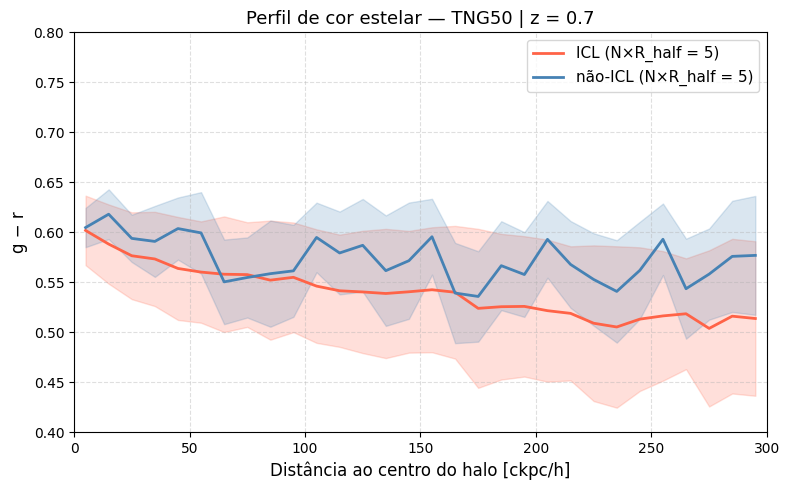

In [9]:
# PLOT

fig, ax = plt.subplots(figsize=(8, 5))

# ICL
mask_icl = np.isfinite(gr_mean_icl)
ax.plot(r_icl[mask_icl], gr_mean_icl[mask_icl],
        color='tomato', lw=2, label=f'ICL (N×R_half = {icl_limit})')
ax.fill_between(r_icl[mask_icl], gr_mean_icl[mask_icl] - gr_std_icl[mask_icl],
                gr_mean_icl[mask_icl] + gr_std_icl[mask_icl], color='tomato', alpha=0.2)

# não-ICL
mask_noicl = np.isfinite(gr_mean_noicl)
ax.plot(r_noicl[mask_noicl], gr_mean_noicl[mask_noicl],
        color='steelblue', lw=2, label=f'não-ICL (N×R_half = {icl_limit})')
ax.fill_between(r_noicl[mask_noicl], gr_mean_noicl[mask_noicl] - gr_std_noicl[mask_noicl],
                gr_mean_noicl[mask_noicl] + gr_std_noicl[mask_noicl], color='steelblue', alpha=0.2)

ax.set_xlabel('Distância ao centro do halo [ckpc/h]', fontsize=12)
ax.set_ylabel('g − r', fontsize=12)
ax.set_title(f'Perfil de cor estelar — TNG50 | z = {zred}', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, radius_cut)
ax.set_ylim(0.4, 0.8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'gr_color_profile_icl_limit{icl_limit}_z{zred}.png', dpi=150)
print("\nGráfico salvo.")
plt.show()